In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url1="https://raw.githubusercontent.com/KarthikaDornipadu/alpha-pulse-financial-analytics/refs/heads/master/Data/clean_prices.csv"
url2="https://raw.githubusercontent.com/KarthikaDornipadu/alpha-pulse-financial-analytics/refs/heads/master/Data/portfolio.csv"


# Ensure df contains the stock prices for returns calculation
df = pd.read_csv(url1, index_col='Date', parse_dates=True)
returns=df.pct_change().dropna()

# Reload weights from portfolio.csv to ensure it's a DataFrame/Series
weights= pd.read_csv(url2)
weights = weights.set_index('Stocks')['weight']

# Reindex weights to align with the columns of the returns DataFrame
weights_for_calc = weights.reindex(df.columns)

# Perform dot product using the aligned weights
portfolio_returns = returns.dot(weights_for_calc)

mean = portfolio_returns.mean()
std_dev = portfolio_returns.std()
print(mean)
print(std_dev)

num_simulations = 10000
num_days = 252

stimulation_results=np.zeros((num_days,num_simulations))

for i in range(num_simulations):
    daily_returns = np.random.normal(mean, std_dev, num_days)
    price_path =100* np.cumprod(1 + daily_returns)
    stimulation_results[:,i]=price_path
print(stimulation_results[:5])

# Save results: Extract only the final day's values for all simulations
final_values = stimulation_results[-1, :]
pd.DataFrame(final_values, columns=["Final Value"]).to_csv("monte_carlo_results.csv")

0.001090365293334896
0.014825387172177913
[[ 99.72114827 102.47426955  96.74125704 ... 100.66182438  99.30173251
  100.29938242]
 [100.23431818 102.54635797  96.92459311 ... 102.14899736  98.55323349
   98.66532693]
 [ 97.81815475 104.90534818  97.35330479 ... 101.44342276 101.28960257
   97.08601828]
 [ 96.30259393 105.9153712   98.18445194 ... 104.61471208 101.08977961
   95.37634017]
 [ 97.35486819 103.96885676  97.61803744 ... 103.95117283 103.90766057
   95.54516635]]


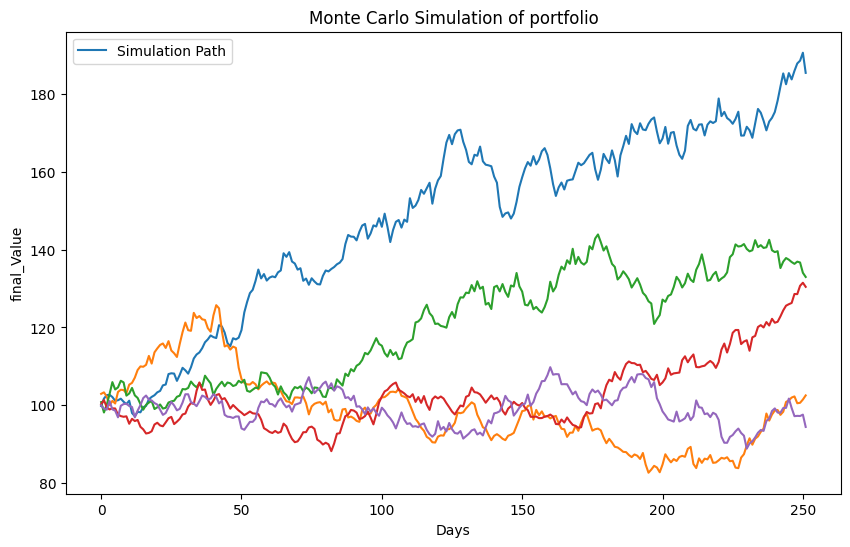

In [3]:
plt.figure(figsize=(10,6))
plt.plot(stimulation_results[:,0], label='Simulation Path')
for i in range(1, 5):
  plt.plot(stimulation_results[:,i])
plt.title('Monte Carlo Simulation of portfolio')
plt.xlabel('Days')
plt.ylabel('final_Value')
plt.legend()
plt.show()

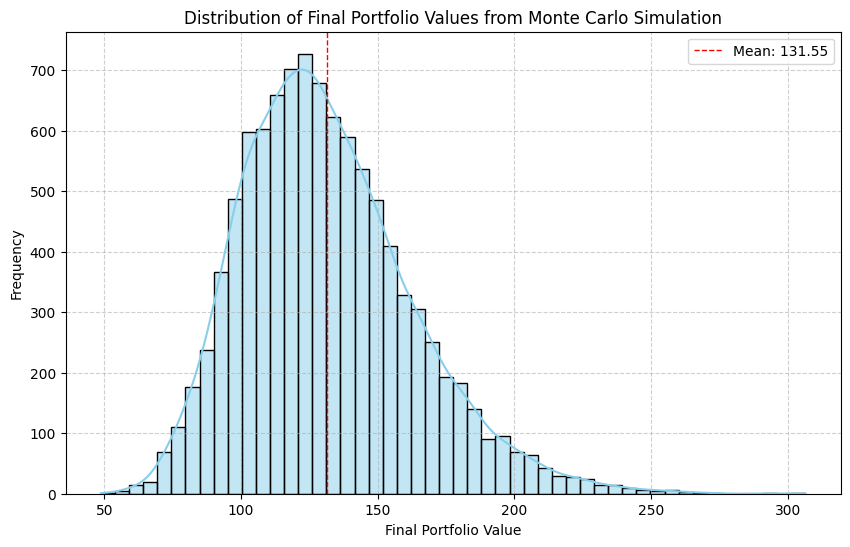

Expected Final Portfolio Value: 131.55
Value at Risk (VaR) at 5.0% confidence: 87.27
Value at Risk (VaR) at 1.0% confidence: 74.08
Conditional Value at Risk (CVaR) at 5.0% confidence: 79.25
Conditional Value at Risk (CVaR) at 1.0% confidence: 68.93


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the final values from the Monte Carlo simulation
monte_carlo_results = pd.read_csv("monte_carlo_results.csv")
final_values = monte_carlo_results["Final Value"]

# Plotting the distribution of final values
plt.figure(figsize=(10, 6))
sns.histplot(final_values, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Final Portfolio Values from Monte Carlo Simulation')
plt.xlabel('Final Portfolio Value')
plt.ylabel('Frequency')
plt.axvline(final_values.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {final_values.mean():.2f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate VaR (Value at Risk)
alpha_5_percent = 0.05
alpha_1_percent = 0.01

# VaR is the value at a certain percentile of the distribution of returns/values.
# A 5% VaR of X means that there is a 5% chance the portfolio will fall below X.
var_95 = np.percentile(final_values, alpha_5_percent * 100)
var_99 = np.percentile(final_values, alpha_1_percent * 100)

print(f"Expected Final Portfolio Value: {final_values.mean():.2f}")
print(f"Value at Risk (VaR) at {alpha_5_percent*100}% confidence: {var_95:.2f}")
print(f"Value at Risk (VaR) at {alpha_1_percent*100}% confidence: {var_99:.2f}")

# Calculate CVaR (Conditional Value at Risk) or Expected Shortfall
# CVaR is the expected loss given that the loss exceeds the VaR.
# It provides a more conservative measure of risk than VaR.

cvar_95 = final_values[final_values <= var_95].mean()
cvar_99 = final_values[final_values <= var_99].mean()

print(f"Conditional Value at Risk (CVaR) at {alpha_5_percent*100}% confidence: {cvar_95:.2f}")
print(f"Conditional Value at Risk (CVaR) at {alpha_1_percent*100}% confidence: {cvar_99:.2f}")

### Stock Correlation Analysis

To understand how the individual stocks in the portfolio move relative to each other, we can calculate and visualize their correlation matrix. This is crucial for portfolio diversification and risk management, as it helps identify stocks that can balance each other out during market fluctuations.

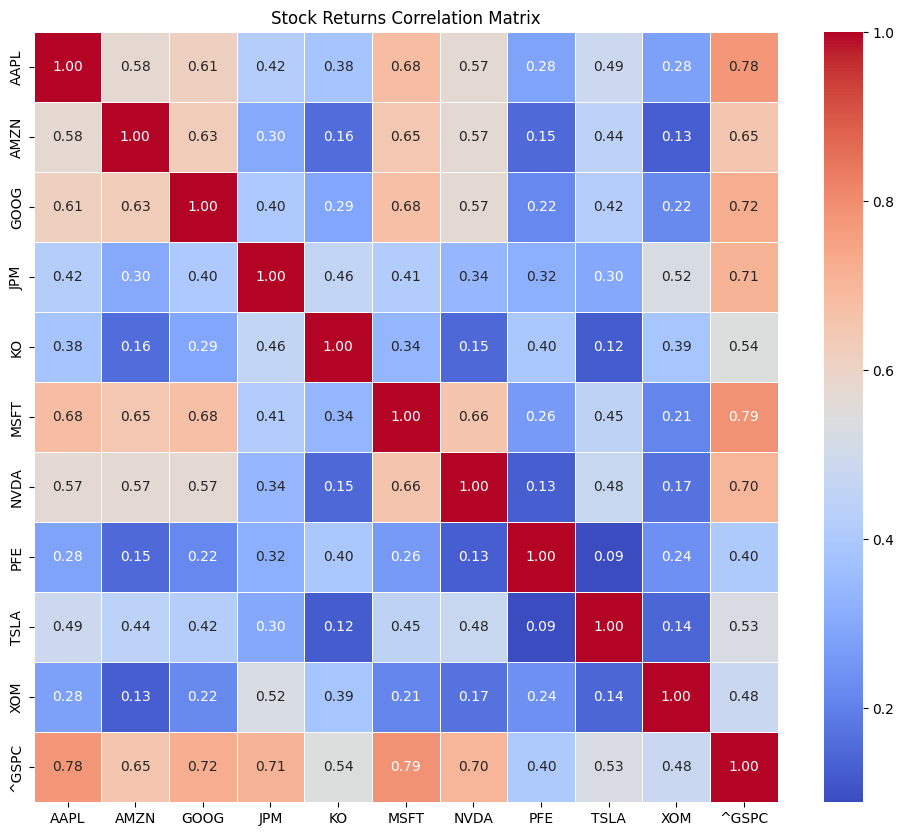

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix of the individual stock returns
correlation_matrix = returns.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Stock Returns Correlation Matrix')
plt.show()